23070521054 - GAURI GULHANE

In [1]:
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input
import matplotlib.pyplot as plt

## Download and Scale Historical Stock Data
We download historical Apple stock prices (`AAPL`) and normalize the close prices using a `MinMaxScaler`.

In [2]:
# Define the stock ticker and date range
TICKER = 'AAPL'
START_DATE = '2010-01-01'
END_DATE = '2023-01-01'

# Download data (auto_adjust=True is now default)
df = yf.download(TICKER, start=START_DATE, end=END_DATE)

# Display the first few rows of the data
print(f"Downloaded data for {TICKER} from {START_DATE} to {END_DATE}.")
display(df.head())

# Use only the 'Close' price for prediction
data = df['Close'].values.reshape(-1, 1)

# Scale the data to be between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)

print("\nScaled data snippet:")
display(scaled_data[:5])

/tmp/ipykernel_4937/3264459374.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=START_DATE, end=END_DATE)
[*********************100%***********************]  1 of 1 completed

Downloaded data for AAPL from 2010-01-01 to 2023-01-01.


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2010-01-04,6.400960,6.415616,6.352207,6.383612,493729600
2010-01-05,6.412030,6.448220,6.378231,6.418610,601904800
2010-01-06,6.310037,6.437452,6.303457,6.412029,552160000
2010-01-07,6.298370,6.340842,6.252608,6.333365,477131200
2010-01-08,6.340243,6.340841,6.252908,6.289995,447610800



Scaled data snippet:


array([[0.00381776],
       [0.0038821 ],
       [0.00328926],
       [0.00322145],
       [0.00346484]])

## Create Temporal Sequences
LSTM networks require a 3D input format: `[samples, time_steps, features]`. We group our sequential data using a 60-day window.

In [3]:
# Function to create sequences for LSTM
def create_sequences(data, time_step=1):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step), 0])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

# Define time step (number of previous days to consider for prediction)
TIME_STEP = 60

# Create features (X) and target (y)
X, y = create_sequences(scaled_data, TIME_STEP)

# Split data into training and testing sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

# Reshape input to [samples, time_steps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (2569, 60, 1)
Shape of y_train: (2569,)
Shape of X_test: (643, 60, 1)
Shape of y_test: (643,)


## Build and Train the LSTM Model
We initialize a Sequential neural network containing two LSTM layers, followed by dense layers to regress to a single close price.

In [4]:
# Build the LSTM model using explicit Input layer
model = Sequential([
    Input(shape=(TIME_STEP, 1)),
    LSTM(units=50, return_sequences=True),
    LSTM(units=50, return_sequences=False),
    Dense(units=25),
    Dense(units=1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=50,
    validation_split=0.1,
    verbose=1
)

print("Model training complete.")

Epoch 1/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 52ms/step - loss: 7.4282e-04 - val_loss: 4.0278e-04
Epoch 2/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step - loss: 3.8748e-05 - val_loss: 3.7462e-04
Epoch 3/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - loss: 3.6012e-05 - val_loss: 2.9133e-04
Epoch 4/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 3.8289e-05 - val_loss: 5.8381e-04
Epoch 5/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 4.0980e-05 - val_loss: 2.4090e-04
Epoch 6/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 3.4316e-05 - val_loss: 2.2865e-04
Epoch 7/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - loss: 2.9014e-05 - val_loss: 4.0107e-04
Epoch 8/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 3.2563e-05 - val_loss: 1.8510e-04
Epoch 9/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 2.6227e-05 - val_loss: 3.0500e-04
Epoch 10/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 2.5875e-05 - val_loss: 2.2850e-04
Epoch 11/50
73/73 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 2.4787e-

## Evaluate predictions and Plot Results
We use the trained network to make predictions on our test set, invert the scaling, and plot our findings.

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


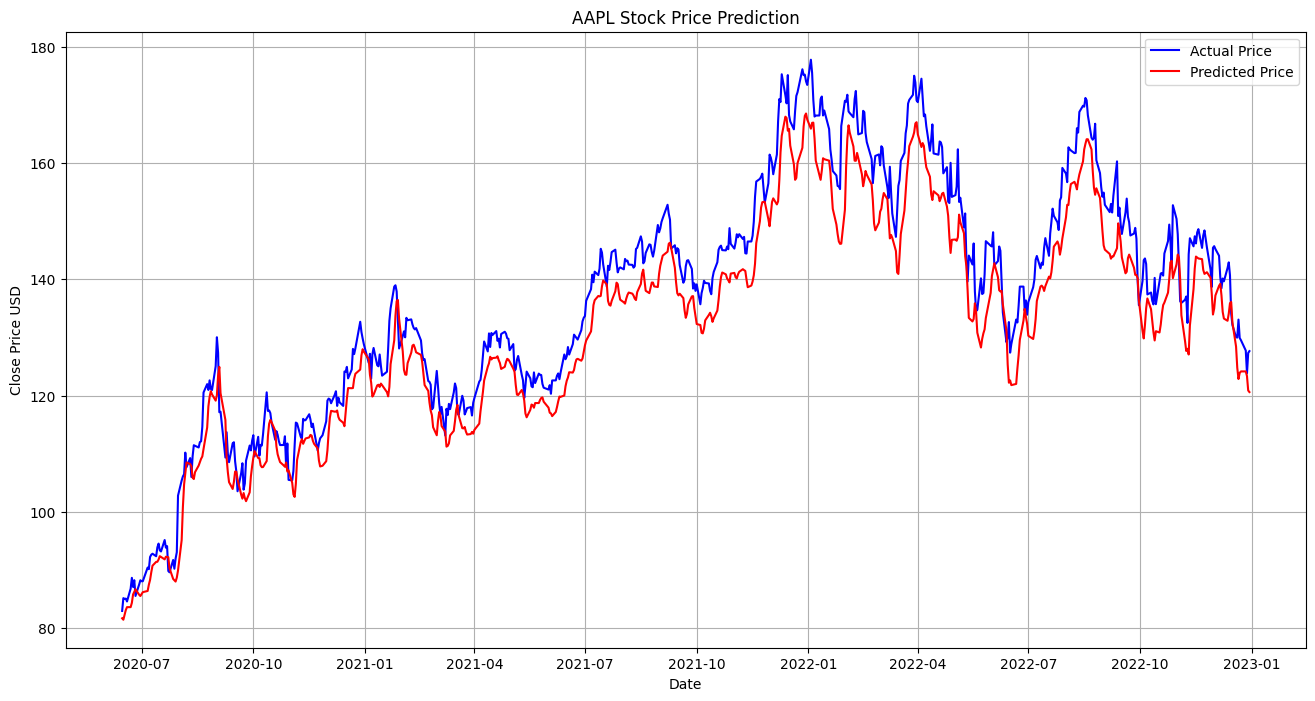

In [5]:
# Make predictions on the test set
test_predictions = model.predict(X_test)

# Inverse transform the predictions and y_test to get actual prices in USD
test_predictions_rescaled = scaler.inverse_transform(test_predictions)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Map correct date ranges to the test predictions
dates_for_plot = df.index[TIME_STEP + train_size:]

# Visualize the results
plt.figure(figsize=(16, 8))
plt.title(f'{TICKER} Stock Price Prediction')
plt.xlabel('Date')
plt.ylabel('Close Price USD')

plt.plot(dates_for_plot, y_test_rescaled, label='Actual Price', color='blue')
plt.plot(dates_for_plot, test_predictions_rescaled, label='Predicted Price', color='red')
plt.legend()
plt.grid(True)
plt.show()